# 03 — Clustering Analysis: The DNA of Genres
**Spotify Dataset 1921–2020** · ~600k tracks · Source: [Kaggle](https://www.kaggle.com/datasets/yamaerenay/spotify-dataset-19212020-600k-tracks)

### Purpose
Do songs naturally group into genre-like clusters based on audio features alone,
independent of any label assigned by Spotify?

### Sections
| # | Section |
|---|---------|
| 1 | Load & setup |
| 2 | Correlation analysis — motivating PCA |
| 3 | Feature engineering (PCA, sqrt transforms) |
| 4 | Stratified sampling |
| 5 | Elbow & silhouette analysis |
| 6 | Cluster profiling (k=3, 5, 7) |
| 7 | Liveness ablation |
| 8 | Final model (k=4) |
| 9 | Findings |


## 0 · Imports & Configuration

In [13]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from shared.config     import PATHS, PALETTE, PALETTE_CLUSTERS, FEATURES, set_style
from shared.plot_utils import make_fig

set_style()

---
## 1 · Load & Setup

In [2]:
tracks_clean = pd.read_parquet(PATHS['clean'])
print(f"Shape : {tracks_clean.shape}")
tracks_clean.head()

Shape : (569604, 28)


,id,name,popularity,duration_min,explicit,artists,id_artists,release_date,danceability,energy,...,tempo,time_signature,main_artist,id_main_artist,key_name,mode_name,year,decade,speechiness_sqrt,instrumentalness_sqrt
0,35iwgR4jXetI318WEWsa1Q,Carve,6,2.115050,0,[Uli],[45tIt06XoI0Iio4LBEVpls],1922-02-22,0.645,0.445,...,104.851,3,Uli,45tIt06XoI0Iio4LBEVpls,C,Major,1922,1920,0.671565,0.862554
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,1.636667,0,[Fernando Pessoa],[14jtPCOoNZwquk5wd9DxrY],1922-06-01,0.695,0.263,...,102.009,1,Fernando Pessoa,14jtPCOoNZwquk5wd9DxrY,C,Major,1922,1920,0.978264,0.000000
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,3.027333,0,[Ignacio Corsini],[5LiOoJbxVSAMkBS2fUm3X2],1922-03-21,0.434,0.177,...,130.418,5,Ignacio Corsini,5LiOoJbxVSAMkBS2fUm3X2,C♯,Major,1922,1920,0.226274,0.147648
3,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,2.718000,0,[Dick Haymes],[3BiJGZsyX9sJchTqcSA7Su],1922-01-01,0.402,0.158,...,103.220,4,Dick Haymes,3BiJGZsyX9sJchTqcSA7Su,D♯,Minor,1922,1920,0.197484,0.360555
4,0BRXJHRNGQ3W4v9frnSfhu,Ave Maria,0,2.982217,0,[Dick Haymes],[3BiJGZsyX9sJchTqcSA7Su],1922-01-01,0.227,0.261,...,118.891,4,Dick Haymes,3BiJGZsyX9sJchTqcSA7Su,F,Major,1922,1920,0.195448,0.496991


---
## 2 · Correlation Analysis — Motivating PCA

Before clustering we examine feature correlations at **track level** to identify
redundant features that would distort cluster geometry.

> **Methodological note — ecological fallacy risk:**
> Correlations on *yearly means* (used in temporal analysis) inflate coefficients.
> For example, `energy ↔ acousticness` shows −1.0 on yearly means but only −0.71
> at track level. All feature decisions here are based on **track-level** correlations.

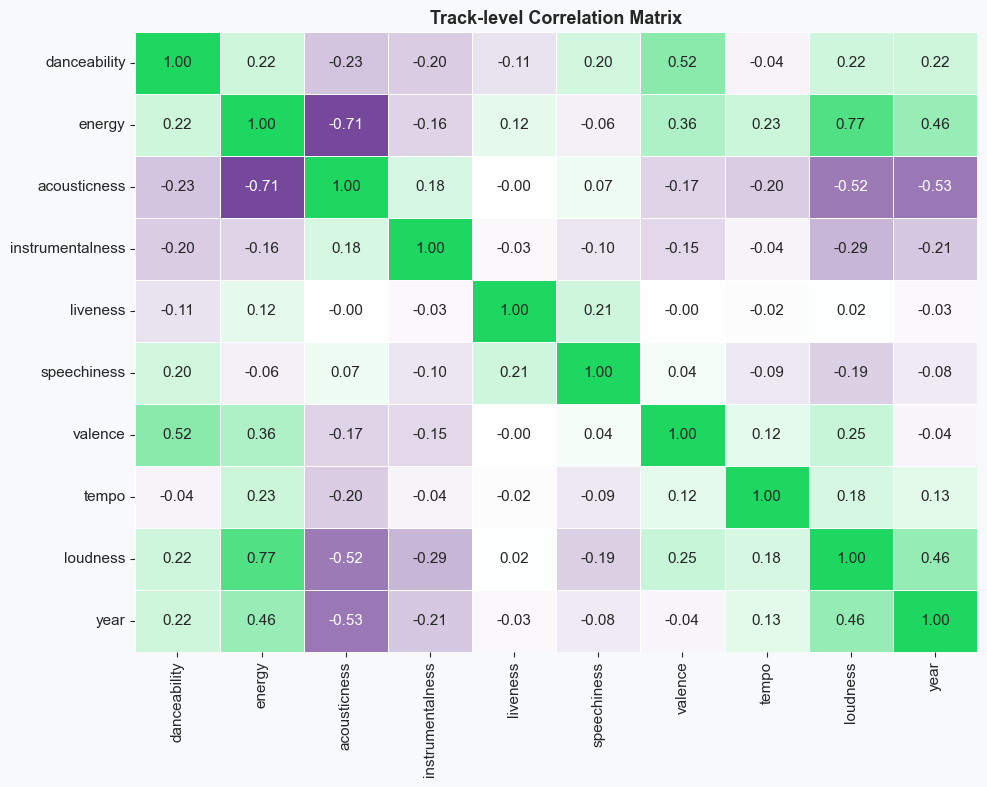

In [3]:
features_for_corr = [
    'danceability', 'energy', 'acousticness',
    'instrumentalness', 'liveness', 'speechiness',
    'valence', 'tempo', 'loudness', 'year'
]

corr_track = tracks_clean[features_for_corr].corr()

fig, ax = make_fig(figsize=(10, 8))
sns.heatmap(
    corr_track,
    annot=True, fmt='.2f',
    cmap='Pu_Gr', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar=False
)
ax.set_title('Track-level Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

### Correlation findings — clustering implications

**Correlated trio: `energy`, `loudness`, `acousticness`**
All three are moderately-to-strongly correlated at track level.
Including all three gives the production-intensity axis triple weight. → **Compress into PC1 via PCA.**

**`year` correlations are moderate but meaningful**
Correlates with acousticness (−0.44), energy (+0.36), loudness (+0.33).
Would create temporal blobs instead of audio-profile clusters. → **Exclude from clustering.**

**`liveness` is near-zero with everything**
Consistent with its flat temporal trajectory. Adds noise without signal. → **Candidate for ablation (Section 7).**

---
## 3 · Feature Engineering

### 3.1 PCA compression of the correlated trio

`energy`, `loudness` and `acousticness` share a single dominant axis (production intensity).
PCA compresses the three features into a single component `pc1_ela`.

In [4]:
# [STEP 1] - Scale the trio — mandatory before PCA
trio_scaled = StandardScaler().fit_transform(
    tracks_clean[['energy', 'loudness', 'acousticness']])

# [STEP 2] - Fit PCA on all 3 components to inspect explained variance
pca_fit = PCA(n_components=3).fit(trio_scaled)

print("Explained variance per component:")
for i, var in enumerate(pca_fit.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.3f}  ({var*100:.1f}%)")

# [STEP 3] - Extract PC1 only
pc1_ela = pca_fit.transform(trio_scaled)[:, 0]

Explained variance per component:
  PC1: 0.779  (77.9%)
  PC2: 0.162  (16.2%)
  PC3: 0.059  (5.9%)


PC1 captures ~78% of the variance — a reasonable tradeoff.
PC2 at ~16% retains some real variance but collapsing it simplifies
the feature space without meaningfully changing cluster archetypes.

### 3.2 Square root transforms for right-skewed features

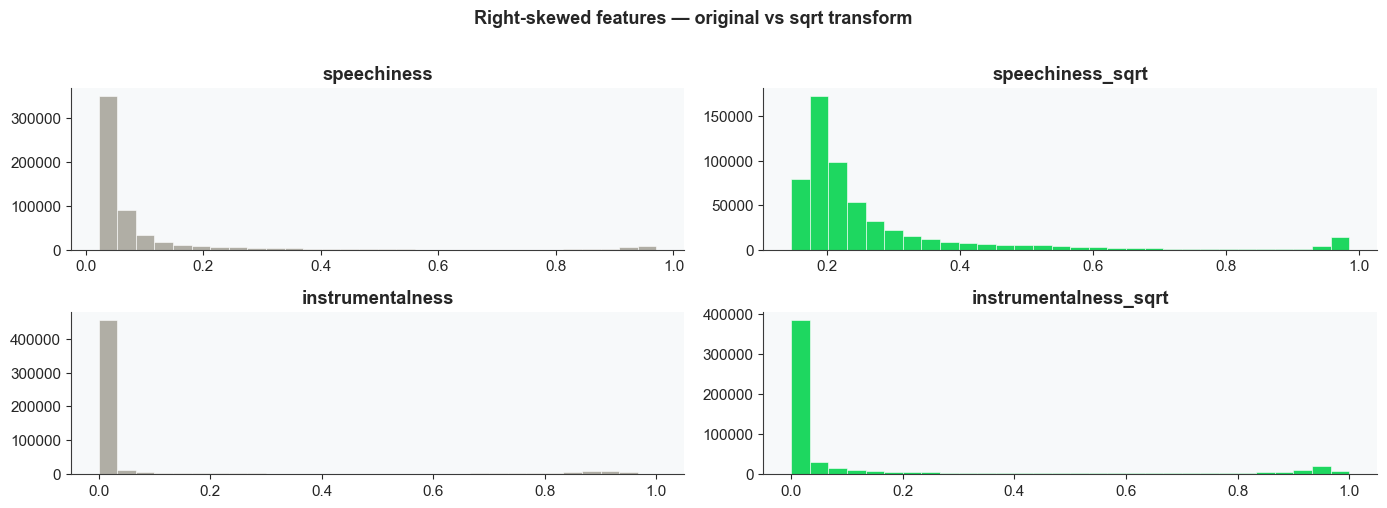

In [5]:
tracks_clean['speechiness_sqrt']      = np.sqrt(tracks_clean['speechiness'])
tracks_clean['instrumentalness_sqrt'] = np.sqrt(tracks_clean['instrumentalness'])

fig, axes = plt.subplots(2, 2, figsize=(14, 5))
axes = axes.flatten()

pairs = [
    ('speechiness',           PALETTE['stone']),
    ('speechiness_sqrt',      PALETTE['green']),
    ('instrumentalness',      PALETTE['stone']),
    ('instrumentalness_sqrt', PALETTE['green']),
]

for ax, (feature, color) in zip(axes, pairs):
    ax.hist(tracks_clean[feature].dropna(), bins=30,
            color=color, edgecolor='white', linewidth=0.4)
    ax.set_title(feature, fontweight='bold')
    sns.despine(ax=ax)

plt.suptitle('Right-skewed features — original vs sqrt transform',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Build clustering feature DataFrame

In [6]:
independent_features = [
    'danceability', 'instrumentalness_sqrt',
    'liveness', 'speechiness_sqrt', 'valence', 'tempo'
]

# [STEP 1] - Start from independent features
tracks_pc = tracks_clean[independent_features].copy()

# [STEP 2] - Attach PC1
tracks_pc['pc1_ela'] = pc1_ela
clustering_features  = independent_features + ['pc1_ela']

# [STEP 3] - Post-hoc columns (not used in clustering — only for interpretation)
for col in ['energy', 'loudness', 'acousticness',
            'instrumentalness', 'speechiness',
            'year', 'decade', 'name', 'artists', 'popularity']:
    tracks_pc[col] = tracks_clean[col].values

tracks_pc['tempo_bpm'] = tracks_pc['tempo'].copy()

print(f"Clustering features : {clustering_features}")
print(f"Feature matrix shape: {tracks_pc[clustering_features].shape}")

Clustering features : ['danceability', 'instrumentalness_sqrt', 'liveness', 'speechiness_sqrt', 'valence', 'tempo', 'pc1_ela']
Feature matrix shape: (569604, 7)


---
## 4 · Stratified Sampling

The dataset is temporally imbalanced — the 2000–2020 period dominates.
A pure random sample would yield ~80% post-2000 content, suppressing
historical genres like Jazz and Classical.

We sample 60,000 tracks **proportionally by year** so every era contributes
relative to its actual presence in the dataset.

In [7]:
SAMPLE_SIZE = 60_000

# [STEP 1] - Stratified sample by year
#            Note: groupby('year') consumes the 'year' column in apply()
#            → reassign it from the index after sampling
clustering_sample = (
    tracks_pc
    .groupby('year', group_keys=False)
    .apply(lambda x: x.sample(frac=SAMPLE_SIZE / len(tracks_pc), random_state=42))
    .reset_index(drop=True)
    .sample(n=SAMPLE_SIZE, random_state=42)
    .reset_index(drop=True)
)

# [STEP 2] - Restore 'year' (dropped by groupby — rejoin from tracks_pc on index)
clustering_sample['year'] = tracks_pc.loc[clustering_sample.index, 'year'].values

X_scaled = StandardScaler().fit_transform(clustering_sample[clustering_features])

print(f"Full dataset   : {len(tracks_clean):,}")
print(f"Sample size    : {len(clustering_sample):,}")
print(f"Feature matrix : {X_scaled.shape}")
print(f"Year range     : {clustering_sample['year'].min()} - {clustering_sample['year'].max()}")

Full dataset   : 569,604
Sample size    : 60,000
Feature matrix : (60000, 7)
Year range     : 1922 - 2021


---
## 5 · Elbow & Silhouette Analysis

Two complementary metrics evaluated for k = 2 to 11:
- **Inertia (elbow):** within-cluster variance — lower is better
- **Silhouette score:** cluster separation quality (−1 to +1) — higher is better

In [8]:
inertia    = []
silhouette = []
k_range    = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(
        silhouette_score(X_scaled, labels, sample_size=10_000, random_state=42))
    print(f"k={k:2d}  inertia={km.inertia_:.0f}  silhouette={silhouette[-1]:.4f}")

k= 2  inertia=344170  silhouette=0.1922
k= 3  inertia=295854  silhouette=0.2193
k= 4  inertia=255974  silhouette=0.2127
k= 5  inertia=228281  silhouette=0.2246
k= 6  inertia=204632  silhouette=0.2095
k= 7  inertia=190882  silhouette=0.2169
k= 8  inertia=180161  silhouette=0.1895
k= 9  inertia=171693  silhouette=0.1813
k=10  inertia=163890  silhouette=0.1795
k=11  inertia=157968  silhouette=0.1779


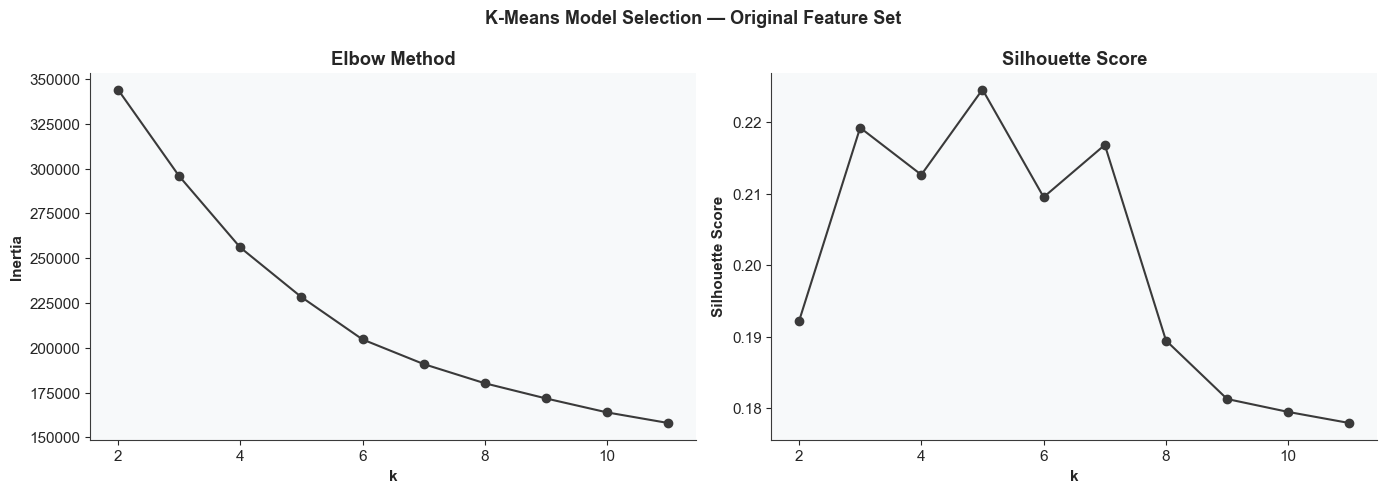

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia, marker='o', color=PALETTE['dark'], linewidth=1.5)
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method', fontweight='bold')
sns.despine(ax=ax1)

ax2.plot(k_range, silhouette, marker='o', color=PALETTE['dark'], linewidth=1.5)
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score', fontweight='bold')
sns.despine(ax=ax2)

plt.suptitle('K-Means Model Selection — Original Feature Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6 · Cluster Profiling — k=3, 5, 7

Paired heatmaps per k value:
- **Left:** normalized profile (0–1 across features) → cluster *shape*
- **Right:** absolute values for readable features → cluster *identity*

In [10]:
readable_cols = ['tempo_bpm', 'loudness', 'energy',
                 'acousticness', 'instrumentalness', 'speechiness']
profiles = {}

for k in [3, 5, 7]:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    clustering_sample[f'cluster_k{k}'] = km.fit_predict(X_scaled)
    profiles[k] = (clustering_sample
                   .groupby(f'cluster_k{k}')[clustering_features]
                   .mean().round(3))

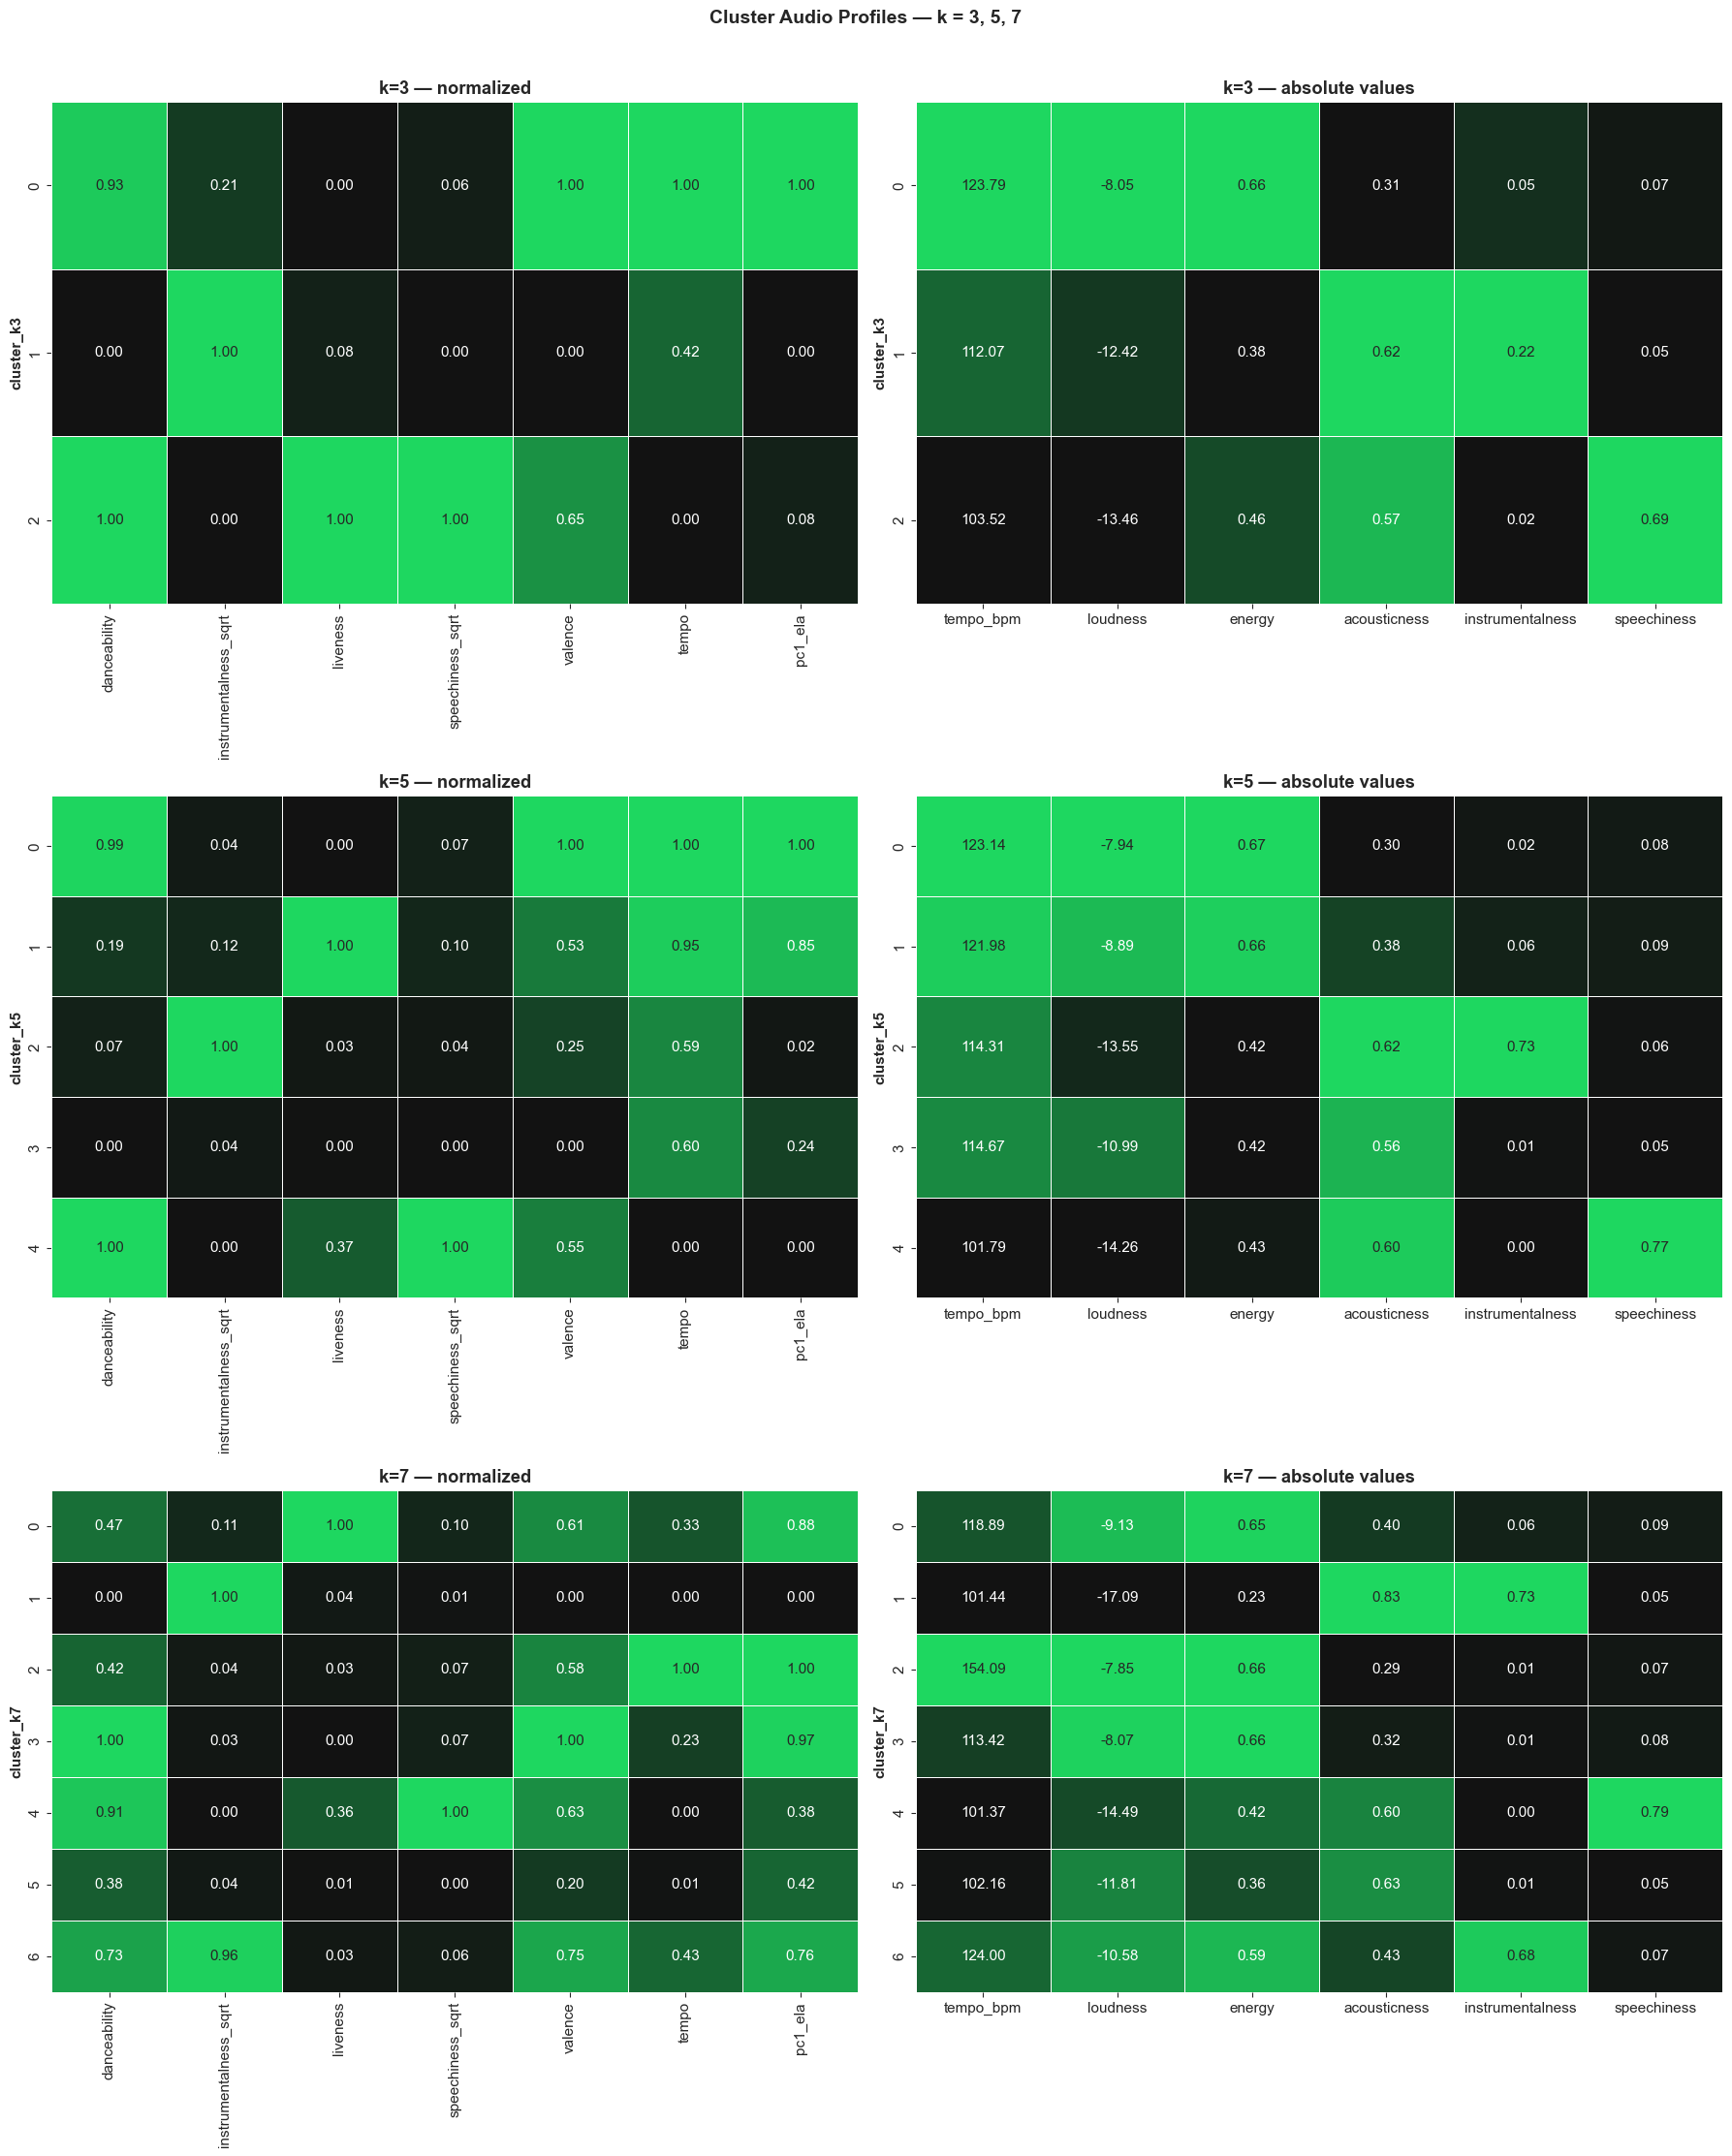

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(18, 22))

for row, k in enumerate([3, 5, 7]):

    profile_norm = pd.DataFrame(
        MinMaxScaler().fit_transform(profiles[k]),
        columns=clustering_features, index=profiles[k].index)

    sns.heatmap(profile_norm, annot=True, fmt='.2f',
                cmap='KGr', linewidths=0.5,
                ax=axes[row, 0], cbar=False)
    axes[row, 0].set_title(f'k={k} — normalized', fontweight='bold')

    profile_abs = (clustering_sample
                   .groupby(f'cluster_k{k}')[readable_cols]
                   .mean().round(2))
    profile_abs_norm = pd.DataFrame(
        MinMaxScaler().fit_transform(profile_abs),
        columns=readable_cols, index=profile_abs.index)

    sns.heatmap(profile_abs_norm, annot=profile_abs, fmt='.2f',
                cmap='KGr', linewidths=0.5,
                ax=axes[row, 1], cbar=False)
    axes[row, 1].set_title(f'k={k} — absolute values', fontweight='bold')

plt.suptitle('Cluster Audio Profiles — k = 3, 5, 7', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

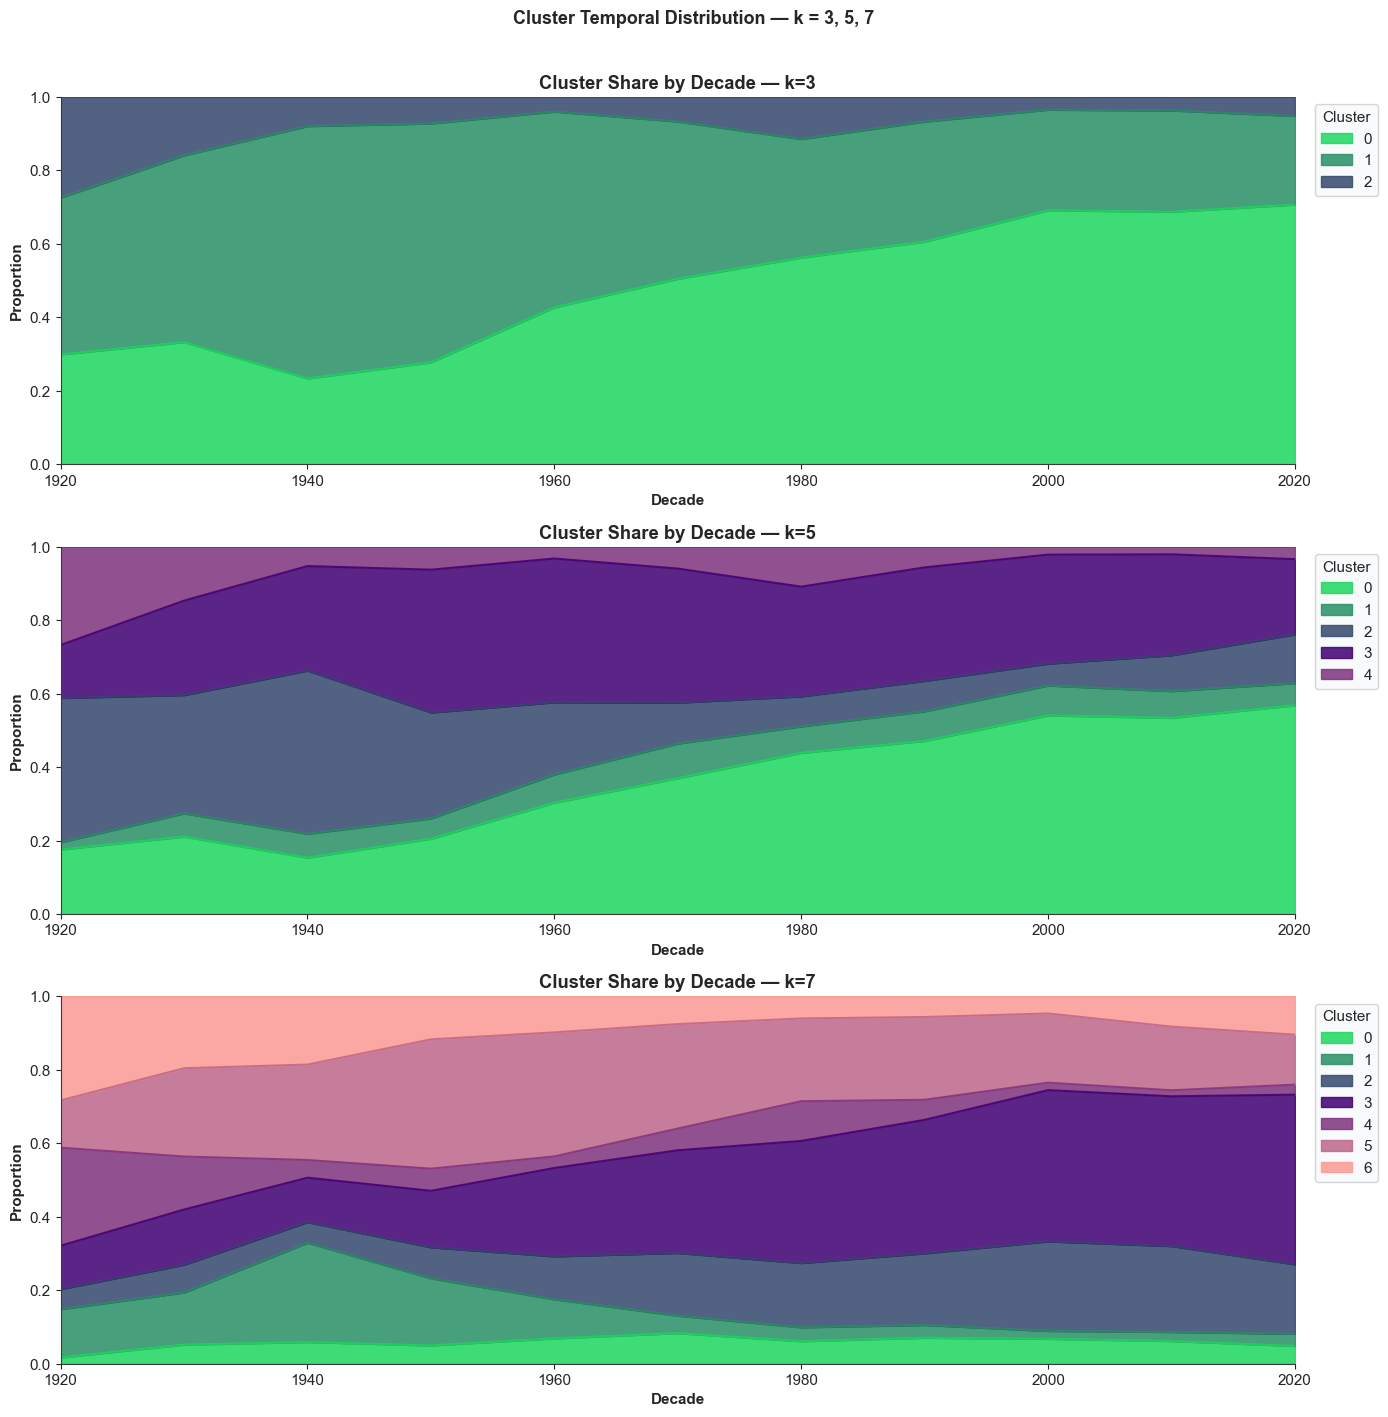

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

for ax, k in zip(axes, [3, 5, 7]):
    decade_counts = (clustering_sample
                     .groupby(['decade', f'cluster_k{k}'])
                     .size().unstack(fill_value=0))
    decade_props = decade_counts.div(decade_counts.sum(axis=1), axis=0)

    decade_props.plot(kind='area', stacked=True, ax=ax,
                      color=PALETTE_CLUSTERS[:k], alpha=0.85, legend=True)
    ax.set_title(f'Cluster Share by Decade — k={k}', fontweight='bold')
    ax.set_xlabel('Decade'); ax.set_ylabel('Proportion')
    ax.set_xlim(decade_props.index.min(), decade_props.index.max())
    ax.set_ylim(0, 1)
    ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Cluster Temporal Distribution — k = 3, 5, 7', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [17]:
# Top 10 popular tracks per cluster — qualitative interpretation
for k in [3, 5, 7]:
    print(f"\n{'=' * 65}  k={k}")
    for cluster_id in sorted(clustering_sample[f'cluster_k{k}'].unique()):
        top10 = (clustering_sample[clustering_sample[f'cluster_k{k}'] == cluster_id]
                 .sort_values('popularity', ascending=False)
                 .head(10)[['name', 'artists', 'popularity']]
                 .reset_index(drop=True))
        top10.index += 1
        print(f"\n  Cluster {cluster_id}\n  {'-'*60}")
        print(top10.to_string())


=================================================================  k=3

  Cluster 0
  ------------------------------------------------------------
                                    name                                              artists  popularity
1                 Astronaut In The Ocean                                        [Masked Wolf]          98
2                        Save Your Tears                                         [The Weeknd]          97
3           Best Friend (feat. Doja Cat)                                 [Saweetie, Doja Cat]          90
4                                Whoopty                                                 [CJ]          89
5                                Hold On                                      [Justin Bieber]          88
6                 No Te Enamores - Remix  [Milly, Farruko, Nio Garcia, Jay Wheeler, Amenazzy]          88
7                           Shape of You                                         [Ed Sheeran]          87
8   

---
## 7 · Liveness Ablation

`liveness` showed near-zero correlation with all features and a flat temporal
trajectory. Hypothesis: it adds noise without contributing signal.
We re-run the full pipeline without it and compare silhouette scores.

In [18]:
independent_features_nolive = [
    'danceability', 'instrumentalness_sqrt',
    'speechiness_sqrt', 'valence', 'tempo'
]
clustering_features_nolive = independent_features_nolive + ['pc1_ela']

X_scaled_nolive = StandardScaler().fit_transform(
    clustering_sample[clustering_features_nolive])

print(f"Original feature matrix : {X_scaled.shape}")
print(f"Ablation feature matrix : {X_scaled_nolive.shape}")

Original feature matrix : (60000, 7)
Ablation feature matrix : (60000, 6)


In [19]:
inertia_nolive    = []
silhouette_nolive = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled_nolive)
    inertia_nolive.append(km.inertia_)
    silhouette_nolive.append(
        silhouette_score(X_scaled_nolive, labels, sample_size=10_000, random_state=42))
    print(f"k={k:2d}  silhouette={silhouette_nolive[-1]:.4f}")

k= 2  silhouette=0.2191
k= 3  silhouette=0.2482
k= 4  silhouette=0.2451
k= 5  silhouette=0.2311
k= 6  silhouette=0.2386
k= 7  silhouette=0.2105
k= 8  silhouette=0.2020
k= 9  silhouette=0.2012
k=10  silhouette=0.2000
k=11  silhouette=0.2037


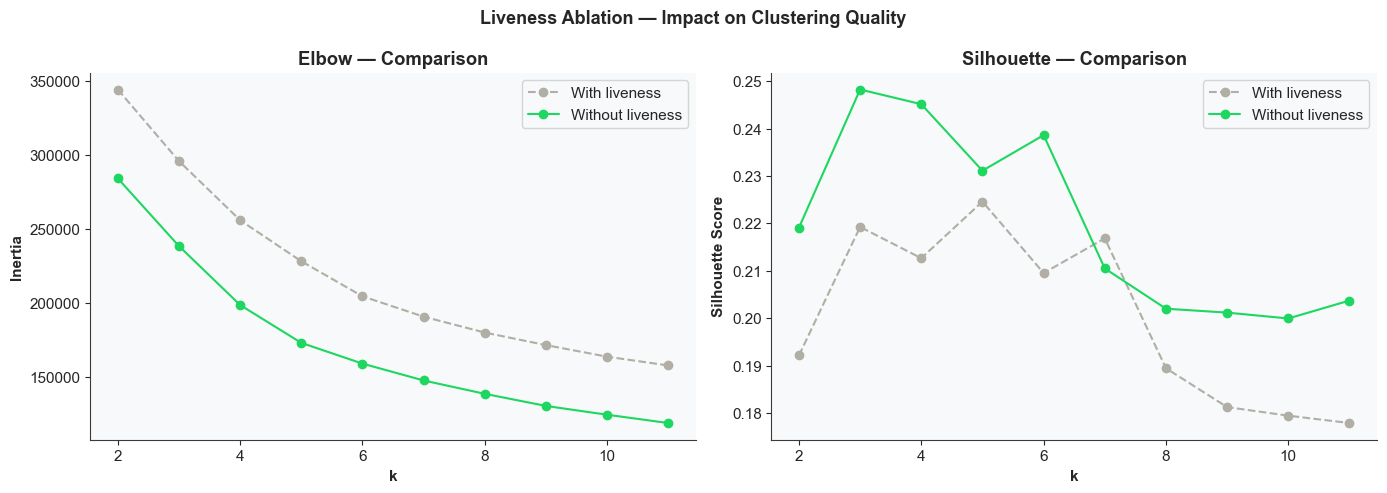

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertia,        marker='o', color=PALETTE['stone'],
         linestyle='--', label='With liveness')
ax1.plot(k_range, inertia_nolive, marker='o', color=PALETTE['green'],
         label='Without liveness')
ax1.set_title('Elbow — Comparison', fontweight='bold')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.legend()
sns.despine(ax=ax1)

ax2.plot(k_range, silhouette,        marker='o', color=PALETTE['stone'],
         linestyle='--', label='With liveness')
ax2.plot(k_range, silhouette_nolive, marker='o', color=PALETTE['green'],
         label='Without liveness')
ax2.set_title('Silhouette — Comparison', fontweight='bold')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score'); ax2.legend()
sns.despine(ax=ax2)

plt.suptitle('Liveness Ablation — Impact on Clustering Quality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Ablation result

Silhouette scores improve across **all k values** after removing liveness,
with no change to cluster archetypes (verified via top-10 track comparison).
Liveness was adding noise. **Decision: use ablated feature set for final model.**

---
## 8 · Final Model — k=4

The ablation silhouette curve peaks at **k=4**, which also produces
the most interpretable cluster archetypes. k=6 retained as secondary model.

In [21]:
profiles_nolive = {}

for k in [4, 6]:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)
    clustering_sample[f'cluster_nolive_k{k}'] = km.fit_predict(X_scaled_nolive)
    profiles_nolive[k] = (clustering_sample
                          .groupby(f'cluster_nolive_k{k}')[clustering_features_nolive]
                          .mean().round(3))

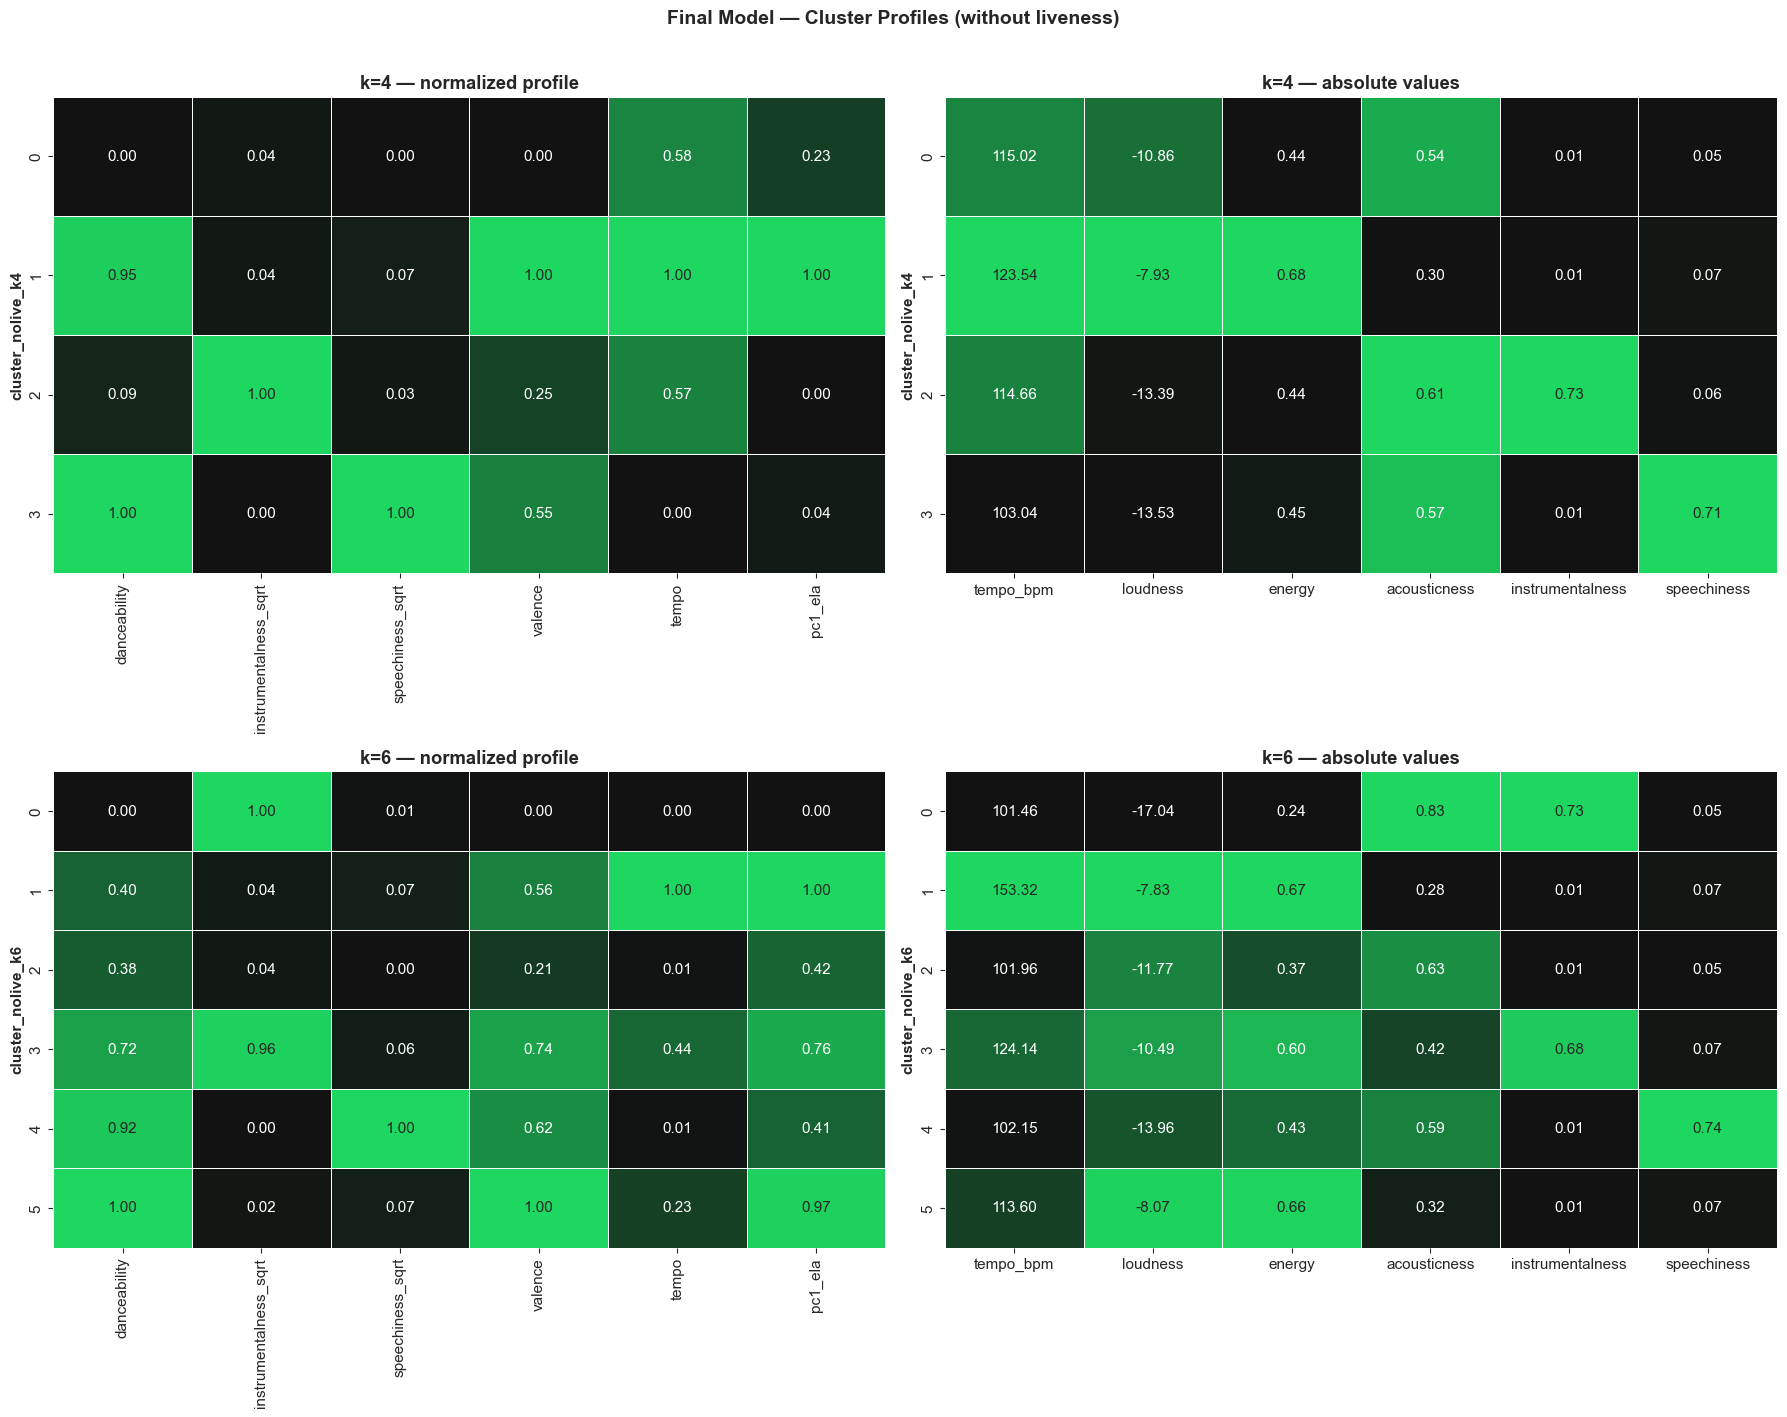

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for row, k in enumerate([4, 6]):

    profile_norm = pd.DataFrame(
        MinMaxScaler().fit_transform(profiles_nolive[k]),
        columns=clustering_features_nolive, index=profiles_nolive[k].index)
    sns.heatmap(profile_norm, annot=True, fmt='.2f',
                cmap='KGr', linewidths=0.5, ax=axes[row, 0], cbar=False)
    axes[row, 0].set_title(f'k={k} — normalized profile', fontweight='bold')

    profile_abs = (clustering_sample
                   .groupby(f'cluster_nolive_k{k}')[readable_cols]
                   .mean().round(2))
    profile_abs_norm = pd.DataFrame(
        MinMaxScaler().fit_transform(profile_abs),
        columns=readable_cols, index=profile_abs.index)
    sns.heatmap(profile_abs_norm, annot=profile_abs, fmt='.2f',
                cmap='KGr', linewidths=0.5, ax=axes[row, 1], cbar=False)
    axes[row, 1].set_title(f'k={k} — absolute values', fontweight='bold')

plt.suptitle('Final Model — Cluster Profiles (without liveness)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

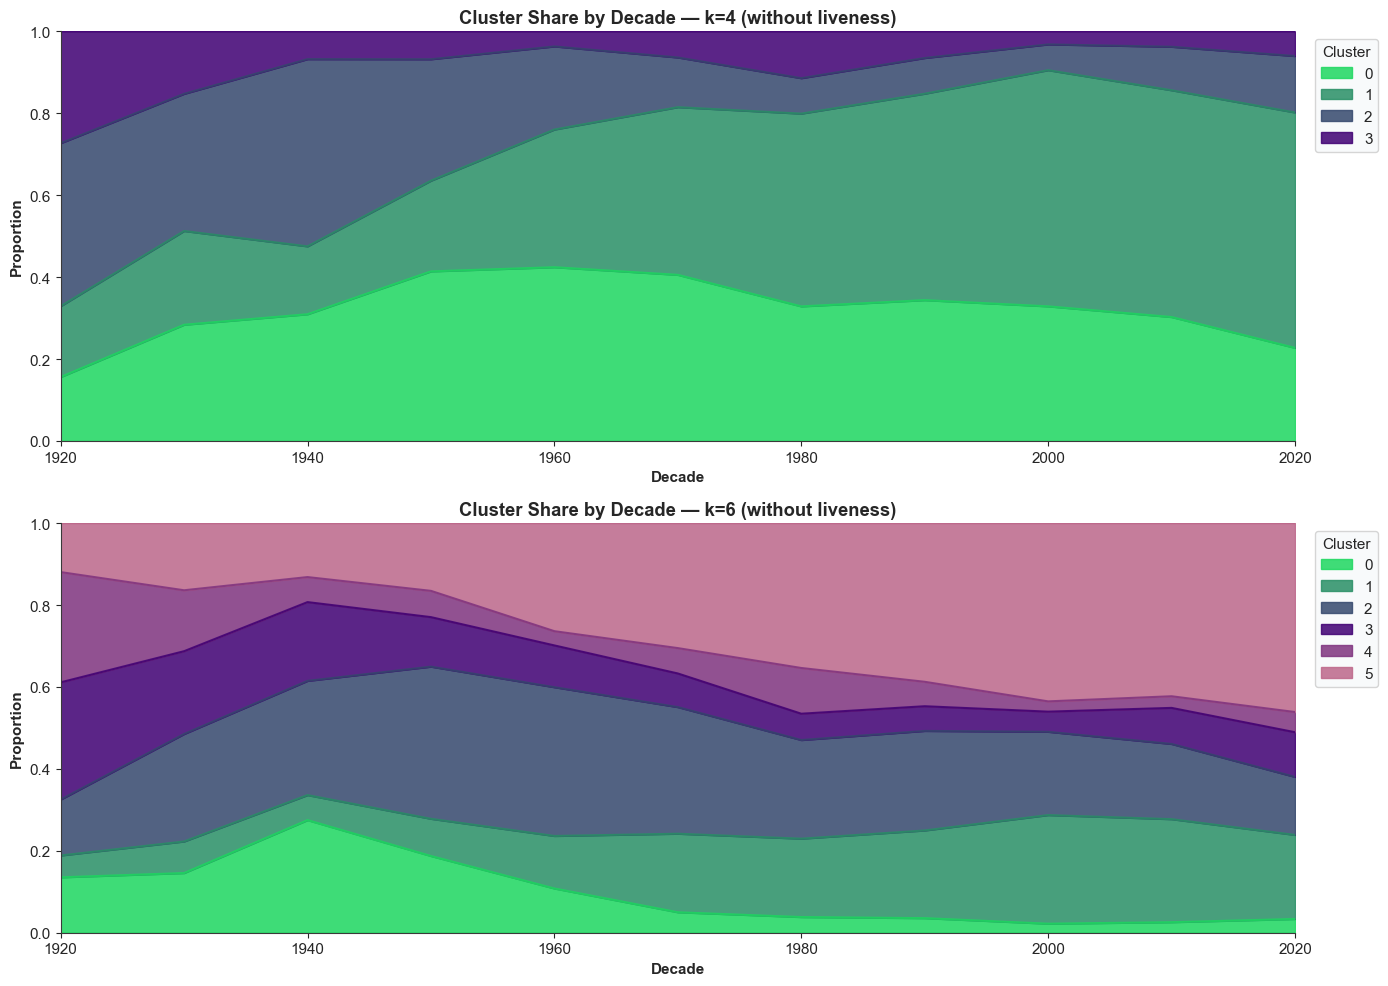

In [23]:
fig, (ax4, ax6) = plt.subplots(2, 1, figsize=(14, 10))

for ax, k in zip([ax4, ax6], [4, 6]):
    decade_counts = (clustering_sample
                     .groupby(['decade', f'cluster_nolive_k{k}'])
                     .size().unstack(fill_value=0))
    decade_props = decade_counts.div(decade_counts.sum(axis=1), axis=0)
    decade_props.plot(kind='area', stacked=True, ax=ax,
                      color=PALETTE_CLUSTERS[:k], alpha=0.85, legend=True)
    ax.set_title(f'Cluster Share by Decade — k={k} (without liveness)', fontweight='bold')
    ax.set_xlabel('Decade'); ax.set_ylabel('Proportion')
    ax.set_xlim(decade_props.index.min(), decade_props.index.max()); ax.set_ylim(0, 1)
    ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [24]:
label_map_k4 = {
    0: 'Soft Pop / R&B',
    1: 'Dance-Pop / Electronic',
    2: 'Classical / Ambient',
    3: 'Hip-Hop / Rap'
}
label_map_k6 = {
    0: 'Classical / Solo Acoustic',
    1: 'EDM / Fast Electronic',
    2: 'Soft / Melancholic',
    3: 'Electronic / Rock',     # flagged as mixed cluster
    4: 'Hip-Hop / Rap',
    5: 'Mainstream Pop'
}

clustering_sample['label_k4'] = clustering_sample['cluster_nolive_k4'].map(label_map_k4)
clustering_sample['label_k6'] = clustering_sample['cluster_nolive_k6'].map(label_map_k6)

print("k=4 distribution:")
print(clustering_sample['label_k4'].value_counts())
print()
print("k=6 distribution:")
print(clustering_sample['label_k6'].value_counts())

k=4 distribution:
label_k4
Dance-Pop / Electronic    27670
Soft Pop / R&B            20416
Classical / Ambient        8048
Hip-Hop / Rap              3866
Name: count, dtype: int64

k=6 distribution:
label_k6
Mainstream Pop               21074
Soft / Melancholic           14811
EDM / Fast Electronic        11931
Electronic / Rock             5098
Classical / Solo Acoustic     3544
Hip-Hop / Rap                 3542
Name: count, dtype: int64


In [25]:
for k, label_col in [(4, 'label_k4'), (6, 'label_k6')]:
    print(f"\n{'=' * 65}  FINAL MODEL k={k}")
    for label in clustering_sample[label_col].unique():
        top10 = (clustering_sample[clustering_sample[label_col] == label]
                 .sort_values('popularity', ascending=False)
                 .head(10)[['name', 'artists', 'popularity']]
                 .reset_index(drop=True))
        top10.index += 1
        print(f"\n  {label}\n  {'-'*60}")
        print(top10.to_string())


=================================================================  FINAL MODEL k=4

  Dance-Pop / Electronic
  ------------------------------------------------------------
                                        name                                              artists  popularity
1                     Astronaut In The Ocean                                        [Masked Wolf]          98
2                            Save Your Tears                                         [The Weeknd]          97
3               Best Friend (feat. Doja Cat)                                 [Saweetie, Doja Cat]          90
4                                    Whoopty                                                 [CJ]          89
5                                    Hold On                                      [Justin Bieber]          88
6                     No Te Enamores - Remix  [Milly, Farruko, Nio Garcia, Jay Wheeler, Amenazzy]          88
7                               Shape of You             

---
## 9 · Findings

### Methodology summary

| Decision | Rationale |
|----------|-----------|
| **Track-level correlations** | Yearly means inflate coefficients (ecological fallacy) — energy ↔ acousticness: −1.0 on means vs −0.71 at track level |
| **PCA on energy/loudness/acousticness** | Three correlated features → `pc1_ela` (77.9% variance explained) |
| **`year` excluded** | Would create temporal blobs instead of audio-profile clusters |
| **`liveness` excluded** | Ablation: silhouette improved across all k; cluster archetypes unchanged |
| **Stratified sampling by year** | Prevents modern-era dominance from suppressing historical genres |

### Final model — k=4 cluster archetypes

| Cluster | Label | Key audio signature |
|---------|-------|---------------------|
| 0 | **Soft Pop / R&B** | High valence, moderate energy, low speechiness |
| 1 | **Dance-Pop / Electronic** | High danceability, high energy, loud |
| 2 | **Classical / Ambient** | High acousticness, high instrumentalness, quiet |
| 3 | **Hip-Hop / Rap** | High speechiness, low acousticness, high tempo |

### Secondary model — k=6
Provides finer granularity. Cluster 3 (Electronic / Rock) is flagged as **mixed** —
tracks sit on the boundary between electronic and guitar-driven rock,
suggesting these genres are not cleanly separable in Spotify's audio feature space.

> **Potential next steps:**
> - Popularity vs cluster: do certain archetypes generate more popular tracks?
> - Artist-level analysis: does artist popularity predict cluster assignment?